C:\Users\Admin\AppData\Local\Temp\ipykernel_34768\706931263.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = df.groupby('symbol').apply(compute_features).reset_index(drop=True)


--- DANH SÁCH 7 MÃ CỔ PHIẾU TỐT NHẤT TỪ RANDOM FOREST ---
  symbol    close  probability
0    DGC    91.50     0.519789
1    BCM    66.00     0.517279
2   VN30  1804.18     0.514656
3    BID    37.40     0.500995
4    CTG    48.00     0.493389
5    GAS    61.20     0.490495
6    GVR    27.95     0.485103


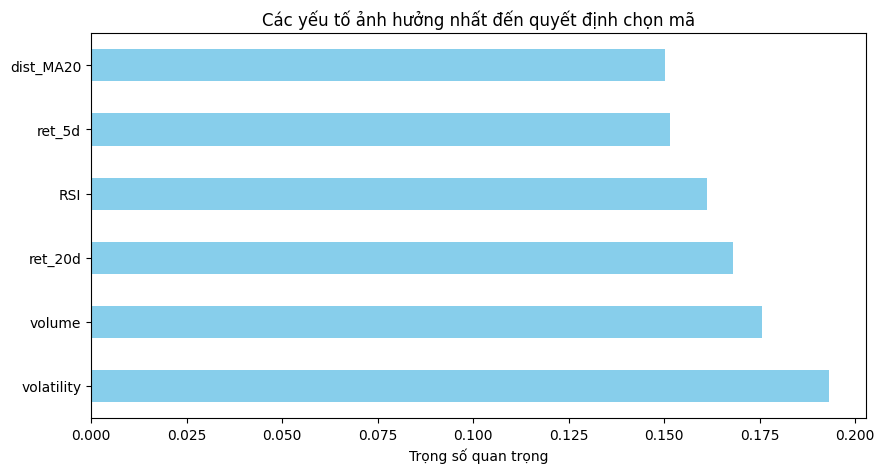

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


df = pd.read_csv('All_VN30_Merged.csv')
df['time'] = pd.to_datetime(df['time'])

def compute_features(group):

    group = group.sort_values('time')

    # Feature 1: Lợi nhuận lũy kế 5 ngày và 20 ngày
    group['ret_5d'] = group['close'].pct_change(5)
    group['ret_20d'] = group['close'].pct_change(20)

    # Feature 2: RSI (Relative Strength Index)
    delta = group['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    group['RSI'] = 100 - (100 / (1 + gain/loss))

    # Feature 3: Độ biến động (Volatility)
    group['volatility'] = group['close'].pct_change().rolling(10).std()

    # Feature 4: So sánh giá với đường trung bình MA20
    group['MA20'] = group['close'].rolling(20).mean()
    group['dist_MA20'] = (group['close'] - group['MA20']) / group['MA20']

    # Target: 1 nếu giá 5 ngày tới tăng, ngược lại 0
    group['target'] = (group['close'].shift(-5) > group['close']).astype(int)

    return group.dropna()

# 2. Áp dụng tính toán cho từng mã cổ phiếu
df_final = df.groupby('symbol').apply(compute_features).reset_index(drop=True)

# 3. Chuẩn bị dữ liệu cho Random Forest
features = ['ret_5d', 'ret_20d', 'RSI', 'volatility', 'dist_MA20', 'volume']
X = df_final[features]
y = df_final['target']

# Huấn luyện mô hình (n_estimators=200 để tăng độ chính xác)
model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
model.fit(X, y)

# 4. PICK 7 MÃ CỔ PHIẾU
# Lấy dữ liệu mới nhất (dòng cuối cùng) của mỗi symbol để dự báo cho tương lai
latest_data = df_final.groupby('symbol').tail(1).copy()

# Dự báo xác suất tăng giá (Probability of Class 1)
latest_data['probability'] = model.predict_proba(latest_data[features])[:, 1]

# Sắp xếp và chọn 7 mã cao nhất
top_7_picks = latest_data.sort_values(by='probability', ascending=False).head(7)

# 5. Hiển thị kết quả
print("--- DANH SÁCH 7 MÃ CỔ PHIẾU TỐT NHẤT TỪ RANDOM FOREST ---")
print(top_7_picks[['symbol', 'close', 'probability']].reset_index(drop=True))

# 6. Vẽ biểu đồ quan trọng của các yếu tố
plt.figure(figsize=(10, 5))
importances = pd.Series(model.feature_importances_, index=features)
importances.nlargest(6).plot(kind='barh', color='skyblue')
plt.title("Các yếu tố ảnh hưởng nhất đến quyết định chọn mã")
plt.xlabel("Trọng số quan trọng")
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, roc_auc_score

# --------------------------------
# 7. Walk-forward validation
# --------------------------------
df_final = df_final.sort_values('time')

train_window = 252 * 2   # 2 năm
test_window = 21         # 1 tháng

dates = df_final['time'].unique()
results = []

for i in range(train_window, len(dates) - test_window, test_window):
    train_dates = dates[i - train_window:i]
    test_dates  = dates[i:i + test_window]

    train_data = df_final[df_final['time'].isin(train_dates)]
    test_data  = df_final[df_final['time'].isin(test_dates)]

    X_train, y_train = train_data[features], train_data['target']
    X_test, y_test   = test_data[features], test_data['target']

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "date": test_dates[-1],
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print("Accuracy trung bình:", results_df['accuracy'].mean())
print("AUC trung bình:", results_df['auc'].mean())

Accuracy trung bình: 0.48950628496083054
AUC trung bình: 0.5131816473676002


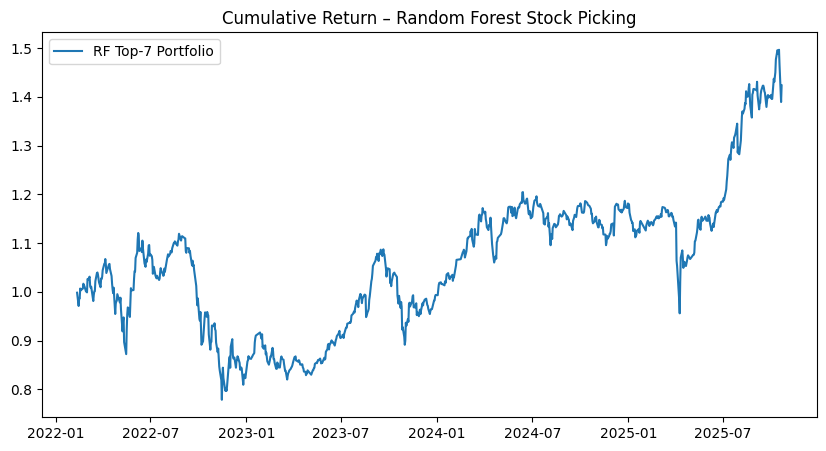

In [24]:
# --------------------------------
# 8. Backtest Top-7 Portfolio
# --------------------------------
portfolio_returns = []

for i in range(train_window, len(dates) - test_window, test_window):
    train_dates = dates[i - train_window:i]
    test_dates  = dates[i:i + test_window]

    train_data = df_final[df_final['time'].isin(train_dates)]
    test_data  = df_final[df_final['time'].isin(test_dates)]

    X_train, y_train = train_data[features], train_data['target']
    model.fit(X_train, y_train)

    # Dự báo xác suất cho đầu kỳ test
    start_test = test_dates[0]
    snapshot = test_data[test_data['time'] == start_test].copy()
    snapshot['prob'] = model.predict_proba(snapshot[features])[:, 1]

    top7 = snapshot.sort_values('prob', ascending=False).head(7)['symbol']

    # Return portfolio (equal weight)
    future = test_data[test_data['symbol'].isin(top7)]
    future_return = future.groupby('time')['close'].mean().pct_change().dropna()

    portfolio_returns.append(future_return)

# Gộp chuỗi lợi suất
portfolio_returns = pd.concat(portfolio_returns)
cum_return = (1 + portfolio_returns).cumprod()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cum_return, label="RF Top-7 Portfolio")
plt.title("Cumulative Return – Random Forest Stock Picking")
plt.legend()
plt.show()


--- BẮT ĐẦU BACKTEST & THEO DÕI DANH MỤC ---

=== LỊCH SỬ CƠ CẤU DANH MỤC (REBALANCING LOG) ===
          Date           Added (IN) Removed (OUT)                    Kept (HOLD)  Turnover_Count
34  2024-12-16             FPT, ACB      BID, CTG                       GVR, DGC               2
35  2025-01-15  BID, VN30, CTG, BCM           GVR                  FPT, ACB, DGC               4
36  2025-02-20             GVR, GAS      BCM, BID       ACB, VN30, DGC, CTG, FPT               2
37  2025-03-21                  BCM           GAS  ACB, VN30, GVR, DGC, CTG, FPT               1
38  2025-04-22             BID, GAS      GVR, DGC       ACB, VN30, CTG, FPT, BCM               2
39  2025-05-26             GVR, DGC      BCM, BID       ACB, VN30, GAS, CTG, FPT               2
40  2025-06-24             BCM, BID      FPT, DGC       ACB, VN30, GVR, GAS, CTG               2
41  2025-07-23             FPT, DGC      BCM, GAS       ACB, VN30, GVR, BID, CTG               2
42  2025-08-21                 

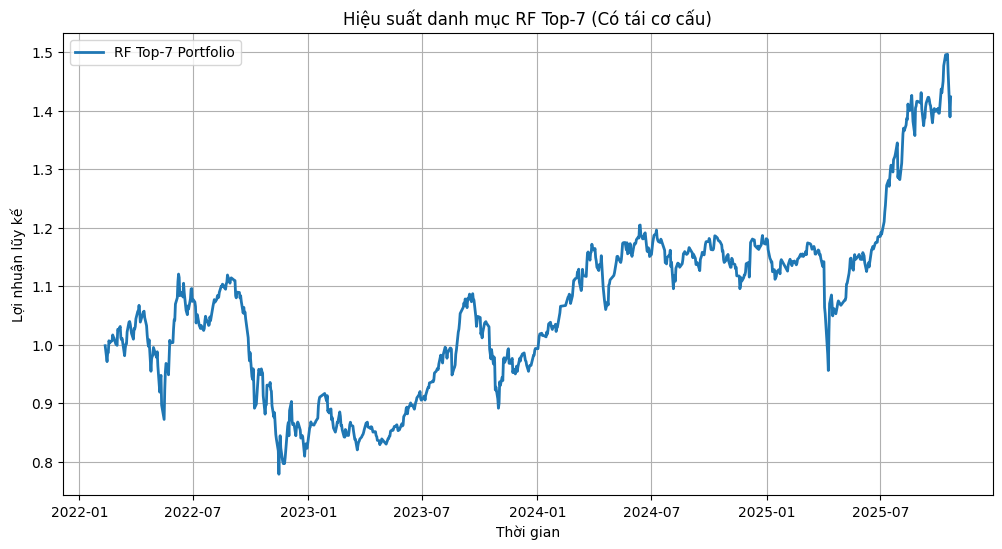

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Khởi tạo danh sách để lưu lịch sử thay đổi
rebalance_history = []
previous_top7 = set() # Tập hợp rỗng ban đầu

portfolio_returns = []

# Giả sử bạn đã có df_final, features, model, dates, train_window, test_window
# Ví dụ: dates = df_final['time'].unique()

print("--- BẮT ĐẦU BACKTEST & THEO DÕI DANH MỤC ---")

for i in range(train_window, len(dates) - test_window, test_window):
    # --- PHẦN CŨ CỦA BẠN (GIỮ NGUYÊN) ---
    train_dates = dates[i - train_window:i]
    test_dates  = dates[i:i + test_window]

    train_data = df_final[df_final['time'].isin(train_dates)]
    test_data  = df_final[df_final['time'].isin(test_dates)]

    X_train, y_train = train_data[features], train_data['target']
    model.fit(X_train, y_train)

    start_test = test_dates[0]
    snapshot = test_data[test_data['time'] == start_test].copy()

    # Dự báo và chọn Top 7
    snapshot['prob'] = model.predict_proba(snapshot[features])[:, 1]
    top7_series = snapshot.sort_values('prob', ascending=False).head(7)['symbol']

    # --- PHẦN MỚI: LOGIC TÌM IN/OUT ---
    current_top7 = set(top7_series.tolist()) # Chuyển về dạng tập hợp (Set)

    if i == train_window:
        # Kỳ đầu tiên: Tất cả đều là Mua mới (IN), không có Bán ra (OUT)
        stocks_in = current_top7
        stocks_out = set()
        stocks_kept = set()
    else:
        # Các kỳ sau: So sánh với kỳ trước
        stocks_in = current_top7 - previous_top7        # Có mới mà cũ không có
        stocks_out = previous_top7 - current_top7       # Có cũ mà mới không có
        stocks_kept = current_top7 & previous_top7      # Giao nhau (Giữ lại)

    # Lưu vào lịch sử
    rebalance_history.append({
        'Date': pd.to_datetime(start_test).date(), # Chỉ lấy ngày cho gọn
        'Added (IN)': ", ".join(list(stocks_in)),
        'Removed (OUT)': ", ".join(list(stocks_out)),
        'Kept (HOLD)': ", ".join(list(stocks_kept)),
        'Turnover_Count': len(stocks_in) # Số lượng mã thay đổi
    })

    # Cập nhật danh mục kỳ trước thành kỳ này cho vòng lặp sau
    previous_top7 = current_top7

    # --- TIẾP TỤC PHẦN TÍNH LỢI NHUẬN CỦA BẠN ---
    future = test_data[test_data['symbol'].isin(current_top7)]
    # Lưu ý: Tính mean returns của các mã trong top 7 tại từng thời điểm trong test_window
    future_return = future.groupby('time')['close'].apply(lambda x: x.pct_change().mean())
    # *Lưu ý nhỏ*: Cách tính future_return ở trên có thể cần điều chỉnh tùy cấu trúc data của bạn
    # để đảm bảo pct_change tính đúng theo chuỗi thời gian của từng mã.
    # Dưới đây là cách an toàn hơn nếu data test_window > 1 ngày:

    # Cách tính return đơn giản hóa cho demo:
    # Lấy lợi nhuận trung bình của 7 mã trong khoảng test_dates
    period_return = future.groupby('time')['close'].mean().pct_change().dropna()
    portfolio_returns.append(period_return)

# --- TỔNG HỢP KẾT QUẢ ---
# 1. Bảng theo dõi IN/OUT
history_df = pd.DataFrame(rebalance_history)

print("\n=== LỊCH SỬ CƠ CẤU DANH MỤC (REBALANCING LOG) ===")
# Hiển thị 10 kỳ thay đổi gần nhất
print(history_df.tail(10).to_string())

# Bạn có thể xuất ra Excel để xem cho dễ
# history_df.to_excel("Portfolio_Rebalancing_Log.xlsx", index=False)

# 2. Vẽ biểu đồ (Phần của bạn)
portfolio_returns = pd.concat(portfolio_returns)
cum_return = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_return, label="RF Top-7 Portfolio", linewidth=2)
plt.title("Hiệu suất danh mục RF Top-7 (Có tái cơ cấu)")
plt.xlabel("Thời gian")
plt.ylabel("Lợi nhuận lũy kế")
plt.legend()
plt.grid(True)
plt.show()